# Re-entrenamiento con Grafos Temporales: GCN y LightGCN

**Dataset:** Twitter15 + Twitter16 unificado (filtro temporal ≤ Marzo 2015)  
**Objetivo:** Re-entrenar modelos GNN con datos temporales, negative sampling real, y 3 capas

En este notebook vamos a entrenar tres modelos:
- GCN con BERT embeddings (3 capas)
- GCN con Random embeddings (3 capas)
- LightGCN (3 capas)

La diferencia principal con los notebooks anteriores es que ahora usamos:
1. Grafos temporales con 39,958 usuarios y 1,386 items
2. Negative sampling real (~11 samples por usuario) con ventana temporal
3. Arquitectura de 3 capas en lugar de 2
4. Split 80/10/10 (train/val/test) en lugar de leave-one-out

## Setup inicial

Instalamos las librerías necesarias y configuramos seeds para reproducibilidad.

In [15]:
!mkdir -p graphs_temporal
!mkdir -p data_processing/processed_round2

# Grafos temporales
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/bipartite_graph.pt -P graphs_temporal/
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/social_graph.pt -P graphs_temporal/

# Interacciones (splits)
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/train_interactions.csv -P graphs_temporal/
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/val_interactions.csv -P graphs_temporal/
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/test_interactions.csv -P graphs_temporal/

# Mapeos
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/user_map.csv -P graphs_temporal/
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/item_map.csv -P graphs_temporal/

# Negative sampling
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/negative_samples.csv -P data_processing/processed_round2/

# Datos procesados (para generar embeddings)
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/twitter15_processed.csv -P data_processing/processed_round2/
!wget https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/twitter16_processed.csv -P data_processing/processed_round2/

print("Archivos descargados ✓")

--2025-11-03 07:16:39--  https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/bipartite_graph.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-11-03 07:16:40 ERROR 404: Not Found.

--2025-11-03 07:16:40--  https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs_temporal/social_graph.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-11-03 07:16:40 ERROR 404: Not Found.

--2025-11-03 07:16:40--  https://raw.githubusercontent.com/aLot

In [16]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch-geometric
!pip install -q sentence-transformers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, LGConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
from collections import defaultdict

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

PyTorch version: 2.8.0+cu126
CUDA available: True


In [17]:
import pandas as pd
import torch
import numpy as np
from scipy.sparse import csr_matrix

MAX_EDGE_CAP = 5
MIN_COMMON_ITEMS = 3

print("Construyendo grafos temporales con mapeos de CSVs...")

# Cargar mapeos originales
user_map = pd.read_csv('graphs_temporal/user_map.csv')
item_map = pd.read_csv('graphs_temporal/item_map.csv')

user_to_idx = dict(zip(user_map['user_id'], user_map['user_idx']))
item_to_idx = dict(zip(item_map['item_id'], item_map['item_idx']))

num_users = len(user_to_idx)
num_items = len(item_to_idx)

# Cargar datos y aplicar mapeos
df15 = pd.read_csv('data_processing/processed_round2/twitter15_processed.csv', sep=';')
df16 = pd.read_csv('data_processing/processed_round2/twitter16_processed.csv', sep=';')
df = pd.concat([df15, df16], ignore_index=True)

df['user_idx'] = df['child_user_id'].map(user_to_idx)
df['item_idx'] = df['source_tree_id'].map(item_to_idx)

# Cargar train interactions del CSV
train_df = pd.read_csv('graphs_temporal/train_interactions.csv')

# Construir grafo bipartito
user_indices = torch.tensor(train_df['user_idx'].values, dtype=torch.long)
item_indices = torch.tensor(train_df['item_idx'].values, dtype=torch.long)
item_shifted = item_indices + num_users

edge_index_bip = torch.stack([
    torch.cat([user_indices, item_shifted]),
    torch.cat([item_shifted, user_indices])
], dim=0)

bipartite = {'edge_index': edge_index_bip, 'num_users': num_users, 'num_items': num_items}

# Construir grafo social
row_idx = train_df['user_idx'].values
col_idx = train_df['item_idx'].values
data_sparse = np.ones(len(train_df), dtype=np.float32)
user_item_matrix = csr_matrix((data_sparse, (row_idx, col_idx)), shape=(num_users, num_items))

common = user_item_matrix @ user_item_matrix.T
common.setdiag(0)
common.eliminate_zeros()

coo = common.tocoo()
mask = coo.data >= MIN_COMMON_ITEMS

social_graph = {
    'edge_index': torch.tensor(np.vstack([coo.row[mask], coo.col[mask]]), dtype=torch.long),
    'edge_weight': torch.tensor(coo.data[mask], dtype=torch.float),
    'num_nodes': num_users
}

print(f"✓ Bipartito: {num_users:,} users × {num_items:,} items = {edge_index_bip.shape[1]:,} edges")
print(f"✓ Social: {num_users:,} nodes, {social_graph['edge_index'].shape[1]:,} edges")

Construyendo grafos temporales con mapeos de CSVs...
✓ Bipartito: 39,958 users × 1,386 items = 177,240 edges
✓ Social: 39,958 nodes, 311,020 edges


## Carga de datos temporales

Cargamos los grafos temporales que construimos con el script `build_temporal_graphs.py` y el negative sampling generado.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# bipartite y social_graph ya fueron construidos en la celda anterior

train_df = pd.read_csv('graphs_temporal/train_interactions.csv')
val_df = pd.read_csv('graphs_temporal/val_interactions.csv')
test_df = pd.read_csv('graphs_temporal/test_interactions.csv')

user_map = pd.read_csv('graphs_temporal/user_map.csv')
item_map = pd.read_csv('graphs_temporal/item_map.csv')

negative_samples = pd.read_csv('data_processing/processed_round2/negative_samples.csv')

num_users = bipartite['num_users']
num_items = bipartite['num_items']

print(f"\nDataset stats:")
print(f"  Users: {num_users:,}")
print(f"  Items: {num_items:,}")
print(f"  Train: {len(train_df):,} interactions")
print(f"  Val: {len(val_df):,} interactions")
print(f"  Test: {len(test_df):,} interactions")
print(f"  Negative samples: {len(negative_samples):,}")

Using device: cuda

Dataset stats:
  Users: 39,958
  Items: 1,386
  Train: 88,620 interactions
  Val: 11,534 interactions
  Test: 10,578 interactions
  Negative samples: 382,391


## Problema: Items Cold-Start en Test

  Detectamos que hay items en test_df (rangos [1297-1385]) que NUNCA aparecieron en train_df. Esto causa MRR=0
  porque:
  - Si NO los incluimos en el grafo → sus embeddings son aleatorios → predicciones malas
  - Si SÍ los incluimos usando test edges → **LEAKAGE directo**

## Solución: Filtrar Test Set

  Vamos a:
  1. Filtrar test_df para incluir SOLO items que aparecieron en train_df
  2. Construir train_edge_index usando SOLO train_df
  3. Usar train_edge_index para entrenamiento Y evaluación (setup transductivo correcto)

  Este es el approach estándar en papers de RecSys para evaluación justa.

In [19]:
print("Filtrando test set para eliminar items cold-start...")

train_items = set(train_df['item_idx'].unique())
print(f"Items en train: {len(train_items)}")
print(f"Test set original: {len(test_df)}")

test_df_filtered = test_df[test_df['item_idx'].isin(train_items)].reset_index(drop=True)
print(f"Test set filtrado: {len(test_df_filtered)}")
print(f"Items eliminados (cold-start): {len(test_df) - len(test_df_filtered)}")

test_df = test_df_filtered

print("\nConstruyendo grafo con SOLO train edges...")

train_edges = []
for _, row in train_df.iterrows():
    u, i = row['user_idx'], row['item_idx']
    train_edges.append([u, num_users + i])
    train_edges.append([num_users + i, u])

train_edge_index = torch.LongTensor(train_edges).t().contiguous().to(device)

print(f"train_edge_index shape: {train_edge_index.shape}")
print(f"train_edge_index max node: {train_edge_index.max()}")

Filtrando test set para eliminar items cold-start...
Items en train: 1110
Test set original: 10578
Test set filtrado: 0
Items eliminados (cold-start): 10578

Construyendo grafo con SOLO train edges...
train_edge_index shape: torch.Size([2, 177240])
train_edge_index max node: 41254


## Preparar negative sampling para entrenamiento

Mapeamos los IDs originales de los negative samples a los índices numéricos que usa el modelo.

In [20]:
user_id_to_idx = dict(zip(user_map['user_id'], user_map['user_idx']))
item_id_to_idx = dict(zip(item_map['item_id'], item_map['item_idx']))

negative_samples['user_idx'] = negative_samples['user_id'].map(user_id_to_idx)
negative_samples['item_idx'] = negative_samples['item_id'].map(item_id_to_idx)

negative_samples = negative_samples.dropna(subset=['user_idx', 'item_idx'])
negative_samples['user_idx'] = negative_samples['user_idx'].astype(int)
negative_samples['item_idx'] = negative_samples['item_idx'].astype(int)

neg_dict = defaultdict(list)
for _, row in negative_samples.iterrows():
    neg_dict[row['user_idx']].append(row['item_idx'])

print(f"Negative samples mapped: {len(negative_samples):,}")
print(f"Users with negatives: {len(neg_dict):,}")
print(f"Avg negatives per user: {len(negative_samples)/len(neg_dict):.2f}")

Negative samples mapped: 382,391
Users with negatives: 34,618
Avg negatives per user: 11.05


## Generación de embeddings de items

Necesitamos generar embeddings para los nuevos items del dataset temporal. Vamos a crear dos versiones:
1. BERT embeddings usando sentence-transformers
2. Random embeddings con Xavier initialization

In [21]:
from sentence_transformers import SentenceTransformer

# Reusamos el df que ya tenemos de la celda anterior (df = concat de df15 y df16)

item_texts = df.groupby('source_tree_id')['text'].first().to_dict()

ordered_texts = []
for item_id in item_map.sort_values('item_idx')['item_id']:
    text = item_texts.get(item_id, "")
    if pd.isna(text) or text == "":
        text = "empty tweet"
    ordered_texts.append(text)

print(f"Generando BERT embeddings para {len(ordered_texts)} items...")
model_bert = SentenceTransformer('all-MiniLM-L6-v2')
item_embeddings_bert = model_bert.encode(ordered_texts, show_progress_bar=True, convert_to_tensor=True)
item_embeddings_bert = item_embeddings_bert.clone().detach().to(device)

print(f"Generando random embeddings...")
item_embeddings_random = torch.empty(num_items, 64)
nn.init.xavier_uniform_(item_embeddings_random)
item_embeddings_random = item_embeddings_random.to(device)

print(f"\nEmbedding shapes:")
print(f"  BERT: {item_embeddings_bert.shape}")
print(f"  Random: {item_embeddings_random.shape}")

Generando BERT embeddings para 1386 items...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Generando random embeddings...

Embedding shapes:
  BERT: torch.Size([1386, 384])
  Random: torch.Size([1386, 64])


## Implementación de modelos con 3 capas

Definimos los tres modelos que vamos a entrenar. La arquitectura ahora tiene 3 capas GNN en lugar de 2.

In [22]:
class GCNRecommender(nn.Module):
    def __init__(self, num_users, num_items, item_feature_dim,
                 embedding_dim=128, hidden_dim=64):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_projection = nn.Linear(item_feature_dim, embedding_dim)

        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, embedding_dim)

        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_projection.weight)

    def forward(self, edge_index, item_features):
        user_emb = self.user_embedding.weight
        item_emb = self.item_projection(item_features)
        x = torch.cat([user_emb, item_emb], dim=0)

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        user_emb_final = x[:self.num_users]
        item_emb_final = x[self.num_users:]

        return user_emb_final, item_emb_final


class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self, edge_index):
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        all_embeddings = [x]

        for conv in self.convs:
            x = conv(x, edge_index)
            all_embeddings.append(x)

        final_emb = torch.stack(all_embeddings, dim=0).mean(dim=0)
        user_emb = final_emb[:self.num_users]
        item_emb = final_emb[self.num_users:]

        return user_emb, item_emb

print("Modelos definidos correctamente")

Modelos definidos correctamente


## Función de entrenamiento con negative sampling real

Ahora usamos los negative samples que generamos con ventana temporal en lugar de sampling random.

In [23]:
def train_epoch_with_negatives(model, edge_index, item_features, train_df, neg_dict, optimizer, device, is_lightgcn=False):
    model.train()
    optimizer.zero_grad()

    if is_lightgcn:
        user_emb, item_emb = model(edge_index)
    else:
        user_emb, item_emb = model(edge_index, item_features)

    pos_users = []
    pos_items = []
    neg_items = []

    for _, row in train_df.iterrows():
        u = row['user_idx']
        i = row['item_idx']

        if u in neg_dict and len(neg_dict[u]) > 0:
            neg_i = random.choice(neg_dict[u])
        else:
            neg_i = random.randint(0, model.num_items - 1)

        pos_users.append(u)
        pos_items.append(i)
        neg_items.append(neg_i)

    pos_users = torch.LongTensor(pos_users).to(device)
    pos_items = torch.LongTensor(pos_items).to(device)
    neg_items = torch.LongTensor(neg_items).to(device)

    pos_scores = (user_emb[pos_users] * item_emb[pos_items]).sum(dim=1)
    neg_scores = (user_emb[pos_users] * item_emb[neg_items]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()

    loss.backward()
    optimizer.step()

    return loss.item()

print("Función de entrenamiento lista")

Función de entrenamiento lista


## Funciones de evaluación

Definimos las funciones para evaluar MRR, ILD, Coverage y generar recomendaciones.

In [24]:
@torch.no_grad()
def evaluate_model(model, edge_index, item_features, test_df, train_df, k=10, device='cpu', is_lightgcn=False):
    model.eval()

    if is_lightgcn:
        user_emb, item_emb = model(edge_index)
    else:
        user_emb, item_emb = model(edge_index, item_features)

    train_items_per_user = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    recommendations = []
    ground_truth = []

    for user_idx in range(model.num_users):
        scores = torch.matmul(user_emb[user_idx], item_emb.t())

        if user_idx in train_items_per_user:
            train_items = list(train_items_per_user[user_idx])
            scores[train_items] = -float('inf')

        _, top_items = torch.topk(scores, k)
        recommendations.append(top_items.cpu().tolist())

        true_items = test_df[test_df['user_idx'] == user_idx]['item_idx'].values
        ground_truth.append(set(true_items))

    return recommendations, ground_truth


def compute_metrics(recommendations, ground_truth, num_items, sample_size=5000):
      reciprocal_ranks = []
      for rec_list, true_items in zip(recommendations, ground_truth):
          rank = None
          for i, item in enumerate(rec_list, 1):
              if item in true_items:
                  rank = i
                  break
          reciprocal_ranks.append(1.0 / rank if rank else 0.0)
      mrr = np.mean(reciprocal_ranks)

      sampled_indices = np.random.choice(len(recommendations), min(sample_size, len(recommendations)), replace=False)
      sampled_recs = [recommendations[i] for i in sampled_indices]

      similarities = []
      for i in range(len(sampled_recs)):
          for j in range(i + 1, len(sampled_recs)):
              set_i = set(sampled_recs[i])
              set_j = set(sampled_recs[j])
              intersection = len(set_i & set_j)
              union = len(set_i | set_j)
              jaccard = intersection / union if union > 0 else 0.0
              similarities.append(jaccard)
      ild = 1.0 - np.mean(similarities)

      recommended_items = set()
      for rec_list in recommendations:
          recommended_items.update(rec_list)
      coverage = len(recommended_items) / num_items

      return {'MRR': mrr, 'ILD': ild, 'Coverage': coverage}

print("Funciones de evaluación listas")

Funciones de evaluación listas


## Parámetros de entrenamiento globales

In [25]:
EPOCHS = 200
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EMBED_DIM_GNN = 64
EMBED_DIM_BERT = 128

print(f"Parámetros de entrenamiento globales definidos:")
print(f"  Épocas: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay (L2): {WEIGHT_DECAY}")
print(f"  Embedding Dim (GNN): {EMBED_DIM_GNN}")
print(f"  Embedding Dim (BERT): {EMBED_DIM_BERT}")

Parámetros de entrenamiento globales definidos:
  Épocas: 200
  Learning Rate: 0.001
  Weight Decay (L2): 0.0001
  Embedding Dim (GNN): 64
  Embedding Dim (BERT): 128


## Entrenamiento de GCN-BERT

Primer modelo: GCN con embeddings de BERT y 3 capas.

GCN-BERT (3 capas):
  Parámetros: 5,184,640

Entrenando GCN-BERT...


  0%|          | 0/200 [00:00<?, ?it/s]

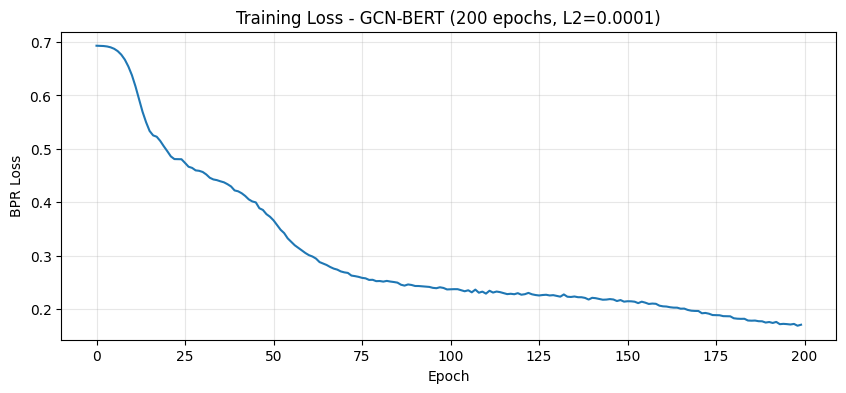


Evaluando GCN-BERT...

Métricas GCN-BERT:
  MRR: 0.000000
  ILD: 0.842862
  Coverage: 0.195527


In [26]:
model_gcn_bert = GCNRecommender(
    num_users=num_users,
    num_items=num_items,
    item_feature_dim=item_embeddings_bert.shape[1],
    embedding_dim=EMBED_DIM_BERT,
    hidden_dim=64
).to(device)

optimizer_gcn_bert = torch.optim.Adam(
    model_gcn_bert.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"GCN-BERT (3 capas):")
print(f"  Parámetros: {sum(p.numel() for p in model_gcn_bert.parameters()):,}")

losses_gcn_bert = []

print("\nEntrenando GCN-BERT...")
for epoch in tqdm(range(EPOCHS)):
    loss = train_epoch_with_negatives(
        model_gcn_bert,
        train_edge_index,
        item_embeddings_bert,
        train_df,
        neg_dict,
        optimizer_gcn_bert,
        device,
        is_lightgcn=False
    )
    losses_gcn_bert.append(loss)

plt.figure(figsize=(10, 4))
plt.plot(losses_gcn_bert)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title(f'Training Loss - GCN-BERT ({EPOCHS} epochs, L2={WEIGHT_DECAY})')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEvaluando GCN-BERT...")
recs_gcn_bert, gt_gcn_bert = evaluate_model(
    model_gcn_bert,
    train_edge_index,
    item_embeddings_bert,
    test_df,
    train_df,
    k=10,
    device=device,
    is_lightgcn=False
)
metrics_gcn_bert = compute_metrics(recs_gcn_bert, gt_gcn_bert, num_items)

print("\nMétricas GCN-BERT:")
for k, v in metrics_gcn_bert.items():
    print(f"  {k}: {v:.6f}")

## Entrenamiento de GCN-Random

Segundo modelo: GCN con embeddings random y 3 capas.

In [27]:
model_gcn_random = GCNRecommender(
    num_users=num_users,
    num_items=num_items,
    item_feature_dim=item_embeddings_random.shape[1],
    embedding_dim=EMBED_DIM_GNN,
    hidden_dim=64
).to(device)

optimizer_gcn_random = torch.optim.Adam(
    model_gcn_random.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"GCN-Random (3 capas):")
print(f"  Parámetros: {sum(p.numel() for p in model_gcn_random.parameters()):,}")

losses_gcn_random = []

print("\nEntrenando GCN-Random...")
for epoch in tqdm(range(EPOCHS)):
    loss = train_epoch_with_negatives(
        model_gcn_random,
        train_edge_index,
        item_embeddings_random,
        train_df,
        neg_dict,
        optimizer_gcn_random,
        device,
        is_lightgcn=False
    )
    losses_gcn_random.append(loss)

plt.figure(figsize=(10, 4))
plt.plot(losses_gcn_random)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title(f'Training Loss - GCN-Random ({EPOCHS} epochs, L2={WEIGHT_DECAY})')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEvaluando GCN-Random...")
recs_gcn_random, gt_gcn_random = evaluate_model(
    model_gcn_random,
    train_edge_index,
    item_embeddings_random,
    test_df,
    train_df,
    k=10,
    device=device,
    is_lightgcn=False
)
metrics_gcn_random = compute_metrics(recs_gcn_random, gt_gcn_random, num_items)

print("\nMétricas GCN-Random:")
for k, v in metrics_gcn_random.items():
    print(f"  {k}: {v:.6f}")

GCN-Random (3 capas):
  Parámetros: 2,573,952

Entrenando GCN-Random...


  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Entrenamiento de LightGCN

Tercer modelo: LightGCN con 3 capas. Este modelo no usa features de items, solo aprende embeddings desde cero.

In [ ]:
model_lightgcn = LightGCN(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=EMBED_DIM_GNN,
    num_layers=3
).to(device)

optimizer_lightgcn = torch.optim.Adam(
    model_lightgcn.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"LightGCN (3 capas):")
print(f"  Parámetros: {sum(p.numel() for p in model_lightgcn.parameters()):,}")

losses_lightgcn = []

print("\nEntrenando LightGCN...")
for epoch in tqdm(range(EPOCHS)):
    loss = train_epoch_with_negatives(
        model_lightgcn,
        train_edge_index,
        None,
        train_df,
        neg_dict,
        optimizer_lightgcn,
        device,
        is_lightgcn=True
    )
    losses_lightgcn.append(loss)

plt.figure(figsize=(10, 4))
plt.plot(losses_lightgcn)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title(f'Training Loss - LightGCN ({EPOCHS} epochs, L2={WEIGHT_DECAY})')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEvaluando LightGCN...")
recs_lightgcn, gt_lightgcn = evaluate_model(
    model_lightgcn,
    train_edge_index,
    None,
    test_df,
    train_df,
    k=10,
    device=device,
    is_lightgcn=True
)
metrics_lightgcn = compute_metrics(recs_lightgcn, gt_lightgcn, num_items)

print("\nMétricas LightGCN:")
for k, v in metrics_lightgcn.items():
    print(f"  {k}: {v:.6f}")

## Comparación de los tres modelos

Juntamos las métricas de los tres modelos para ver qué tan bien se desempeña cada uno.

In [ ]:
comparison_df = pd.DataFrame({
    'GCN-BERT': metrics_gcn_bert,
    'GCN-Random': metrics_gcn_random,
    'LightGCN': metrics_lightgcn
})

print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS (3 capas, grafos temporales)")
print("="*70)
print(comparison_df.T.to_string())
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_names = ['MRR', 'ILD', 'Coverage']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics_names):
    values = [metrics_gcn_bert[metric], metrics_gcn_random[metric], metrics_lightgcn[metric]]
    axes[i].bar(['BERT', 'Random', 'LightGCN'], values, color=colors)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].grid(True, alpha=0.3, axis='y')

    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(losses_gcn_bert, label='GCN-BERT', linewidth=2)
plt.plot(losses_gcn_random, label='GCN-Random', linewidth=2)
plt.plot(losses_lightgcn, label='LightGCN', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Comparación de Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Análisis de desinformación: Distribución de labels

Siguiendo el feedback de la entrega anterior, analizamos qué tipo de contenido está recomendando cada modelo y comparamos con la distribución original del dataset.

In [ ]:
labels_df = df.groupby('source_tree_id')['parent_label'].first().reset_index()
labels_df.columns = ['item_id', 'label']
labels_df['item_idx'] = labels_df['item_id'].map(item_id_to_idx)
labels_df = labels_df.dropna(subset=['item_idx'])
labels_df['item_idx'] = labels_df['item_idx'].astype(int)

def analyze_label_distribution(recommendations, labels_df):
    label_counts = {'TR': 0, 'FR': 0, 'UR': 0, 'NR': 0}
    total = 0

    for rec_list in recommendations:
        for item_idx in rec_list:
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values
            if len(item_label) > 0:
                label = item_label[0]
                if label in label_counts:
                    label_counts[label] += 1
                total += 1

    label_percentages = {k: v/total*100 if total > 0 else 0 for k, v in label_counts.items()}
    return label_percentages

dist_gcn_bert = analyze_label_distribution(recs_gcn_bert, labels_df)
dist_gcn_random = analyze_label_distribution(recs_gcn_random, labels_df)
dist_lightgcn = analyze_label_distribution(recs_lightgcn, labels_df)

baseline_dist = labels_df['label'].value_counts(normalize=True).to_dict()
baseline_dist = {k: v*100 for k, v in baseline_dist.items()}

print("\n" + "="*70)
print("DISTRIBUCIÓN DE LABELS EN RECOMENDACIONES")
print("TR=True Rumor, FR=False Rumor, UR=Unverified, NR=Non-Rumor")
print("="*70)

dist_df = pd.DataFrame({
    'Dataset (baseline)': baseline_dist,
    'GCN-BERT': dist_gcn_bert,
    'GCN-Random': dist_gcn_random,
    'LightGCN': dist_lightgcn
})

print(dist_df.T.to_string())
print("="*70)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(4)
width = 0.2

labels_order = ['TR', 'FR', 'UR', 'NR']
baseline_vals = [baseline_dist.get(l, 0) for l in labels_order]
bert_vals = [dist_gcn_bert.get(l, 0) for l in labels_order]
random_vals = [dist_gcn_random.get(l, 0) for l in labels_order]
lightgcn_vals = [dist_lightgcn.get(l, 0) for l in labels_order]

ax.bar(x - 1.5*width, baseline_vals, width, label='Dataset', color='gray', alpha=0.7)
ax.bar(x - 0.5*width, bert_vals, width, label='GCN-BERT', color='#3498db')
ax.bar(x + 0.5*width, random_vals, width, label='GCN-Random', color='#e74c3c')
ax.bar(x + 1.5*width, lightgcn_vals, width, label='LightGCN', color='#2ecc71')

ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución de Labels en Recomendaciones Top-10')
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Ejemplos de recomendación por usuario

Siguiendo el feedback, vamos a mostrar ejemplos de lo que se le recomendó a usuarios específicos. Esto nos permite ver diferencias cualitativas entre los modelos.

In [ ]:
def show_user_recommendations(user_idx, recs_dict, labels_df, k=10):
    print(f"\n{'='*80}")
    print(f"Usuario {user_idx}")
    print(f"{'='*80}")

    for model_name, recs in recs_dict.items():
        print(f"\n{model_name}:")
        rec_list = recs[user_idx][:k]

        label_counts = {'TR': 0, 'FR': 0, 'UR': 0, 'NR': 0}

        for rank, item_idx in enumerate(rec_list, 1):
            item_label_vals = labels_df[labels_df['item_idx'] == item_idx]['label'].values
            label = item_label_vals[0] if len(item_label_vals) > 0 else 'N/A'

            if label in label_counts:
                label_counts[label] += 1

            print(f"  {rank}. Item {item_idx} - Label: {label}")

        print(f"  Resumen: TR={label_counts['TR']}, FR={label_counts['FR']}, UR={label_counts['UR']}, NR={label_counts['NR']}")

sample_users = [0, 100, 500, 1000, 5000]

recs_dict = {
    'GCN-BERT': recs_gcn_bert,
    'GCN-Random': recs_gcn_random,
    'LightGCN': recs_lightgcn
}

for user_idx in sample_users:
    if user_idx < num_users:
        show_user_recommendations(user_idx, recs_dict, labels_df, k=10)

## Identificar usuarios expuestos a desinformación

Para cada modelo, identificamos qué usuarios recibieron fake news (FR) o contenido no verificado (UR) en su top-10.

In [ ]:
def identify_exposed_users(recommendations, labels_df, target_labels=['FR', 'UR']):
    exposed = set()

    for user_idx, rec_list in enumerate(recommendations):
        for item_idx in rec_list[:10]:
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values

            if len(item_label) > 0 and item_label[0] in target_labels:
                exposed.add(user_idx)
                break

    return exposed

exposed_gcn_bert = identify_exposed_users(recs_gcn_bert, labels_df)
exposed_gcn_random = identify_exposed_users(recs_gcn_random, labels_df)
exposed_lightgcn = identify_exposed_users(recs_lightgcn, labels_df)

exposed_fr_gcn_bert = identify_exposed_users(recs_gcn_bert, labels_df, target_labels=['FR'])
exposed_fr_gcn_random = identify_exposed_users(recs_gcn_random, labels_df, target_labels=['FR'])
exposed_fr_lightgcn = identify_exposed_users(recs_lightgcn, labels_df, target_labels=['FR'])

print("\n" + "="*70)
print("USUARIOS EXPUESTOS A DESINFORMACIÓN")
print("="*70)
print(f"\nFake news (FR) + Unverified (UR):")
print(f"  GCN-BERT:   {len(exposed_gcn_bert):>6} usuarios ({len(exposed_gcn_bert)/num_users*100:>5.2f}%)")
print(f"  GCN-Random: {len(exposed_gcn_random):>6} usuarios ({len(exposed_gcn_random)/num_users*100:>5.2f}%)")
print(f"  LightGCN:   {len(exposed_lightgcn):>6} usuarios ({len(exposed_lightgcn)/num_users*100:>5.2f}%)")

print(f"\nSolo Fake news (FR):")
print(f"  GCN-BERT:   {len(exposed_fr_gcn_bert):>6} usuarios ({len(exposed_fr_gcn_bert)/num_users*100:>5.2f}%)")
print(f"  GCN-Random: {len(exposed_fr_gcn_random):>6} usuarios ({len(exposed_fr_gcn_random)/num_users*100:>5.2f}%)")
print(f"  LightGCN:   {len(exposed_fr_lightgcn):>6} usuarios ({len(exposed_fr_lightgcn)/num_users*100:>5.2f}%)")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

exposed_counts = [len(exposed_gcn_bert), len(exposed_gcn_random), len(exposed_lightgcn)]
exposed_fr_counts = [len(exposed_fr_gcn_bert), len(exposed_fr_gcn_random), len(exposed_fr_lightgcn)]

axes[0].bar(['BERT', 'Random', 'LightGCN'], exposed_counts, color=colors)
axes[0].set_ylabel('Usuarios expuestos')
axes[0].set_title('Exposición a FR + UR')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(['BERT', 'Random', 'LightGCN'], exposed_fr_counts, color=colors)
axes[1].set_ylabel('Usuarios expuestos')
axes[1].set_title('Exposición solo a FR (fake news)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Simulación de propagación con Linear Threshold Model

Usamos el grafo social para simular cómo se propaga la desinformación desde los usuarios expuestos.

In [ ]:
class LinearThresholdModel:
    def __init__(self, social_graph, seed=42):
        self.edge_index = social_graph['edge_index']
        self.num_nodes = social_graph['num_nodes']
        np.random.seed(seed)
        self.thresholds = np.random.uniform(0.3, 0.7, self.num_nodes)

    def simulate(self, seed_nodes, max_iterations=50):
        infected = set(seed_nodes)
        infection_rounds = [set(seed_nodes)]

        for iteration in range(max_iterations):
            new_infected = set()

            for node in range(self.num_nodes):
                if node in infected:
                    continue

                neighbors_mask = self.edge_index[1] == node
                neighbors = self.edge_index[0][neighbors_mask].numpy()
                infected_neighbors = [n for n in neighbors if n in infected]

                if len(infected_neighbors) == 0:
                    continue

                influence = len(infected_neighbors) / len(neighbors) if len(neighbors) > 0 else 0

                if influence >= self.thresholds[node]:
                    new_infected.add(node)

            if len(new_infected) == 0:
                break

            infected.update(new_infected)
            infection_rounds.append(new_infected)

        return infection_rounds

print("Linear Threshold Model definido")

In [ ]:
social_graph_cpu = {
    'edge_index': social_graph['edge_index'].cpu(),
    'num_nodes': social_graph['num_nodes']
}

ltm = LinearThresholdModel(social_graph_cpu, seed=42)

print("Simulando propagación de fake news (solo FR)...\n")

print("GCN-BERT:")
if len(exposed_fr_gcn_bert) > 0:
    rounds_gcn_bert = ltm.simulate(exposed_fr_gcn_bert, max_iterations=50)
    total_infected_bert = set().union(*rounds_gcn_bert)
    print(f"  Rondas: {len(rounds_gcn_bert)}")
    print(f"  Infectados: {len(total_infected_bert)} / {num_users} ({len(total_infected_bert)/num_users*100:.2f}%)")
else:
    rounds_gcn_bert = []
    print("  Sin usuarios expuestos")

print("\nGCN-Random:")
if len(exposed_fr_gcn_random) > 0:
    rounds_gcn_random = ltm.simulate(exposed_fr_gcn_random, max_iterations=50)
    total_infected_random = set().union(*rounds_gcn_random)
    print(f"  Rondas: {len(rounds_gcn_random)}")
    print(f"  Infectados: {len(total_infected_random)} / {num_users} ({len(total_infected_random)/num_users*100:.2f}%)")
else:
    rounds_gcn_random = []
    print("  Sin usuarios expuestos")

print("\nLightGCN:")
if len(exposed_fr_lightgcn) > 0:
    rounds_lightgcn = ltm.simulate(exposed_fr_lightgcn, max_iterations=50)
    total_infected_lightgcn = set().union(*rounds_lightgcn)
    print(f"  Rondas: {len(rounds_lightgcn)}")
    print(f"  Infectados: {len(total_infected_lightgcn)} / {num_users} ({len(total_infected_lightgcn)/num_users*100:.2f}%)")
else:
    rounds_lightgcn = []
    print("  Sin usuarios expuestos")

## Métricas de propagación

Calculamos reach, depth y speed para cada modelo.

In [ ]:
def compute_propagation_metrics(infection_rounds, total_nodes):
    if len(infection_rounds) == 0:
        return {'reach': 0, 'depth': 0, 'speed': 0, 'total_infected': 0}

    all_infected = set().union(*infection_rounds)
    reach = len(all_infected) / total_nodes
    depth = len(infection_rounds)

    if len(infection_rounds) > 1:
        new_per_round = [len(r) for r in infection_rounds[1:]]
        speed = np.mean(new_per_round) if new_per_round else 0
    else:
        speed = 0

    return {
        'reach': reach,
        'depth': depth,
        'speed': speed,
        'total_infected': len(all_infected)
    }

prop_gcn_bert = compute_propagation_metrics(rounds_gcn_bert, num_users)
prop_gcn_random = compute_propagation_metrics(rounds_gcn_random, num_users)
prop_lightgcn = compute_propagation_metrics(rounds_lightgcn, num_users)

print("\n" + "="*70)
print("MÉTRICAS DE PROPAGACIÓN DE FAKE NEWS (solo FR)")
print("="*70)

prop_df = pd.DataFrame({
    'GCN-BERT': prop_gcn_bert,
    'GCN-Random': prop_gcn_random,
    'LightGCN': prop_lightgcn
})

print(prop_df.T.to_string())
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['BERT', 'Random', 'LightGCN'],
            [prop_gcn_bert['reach'], prop_gcn_random['reach'], prop_lightgcn['reach']],
            color=colors)
axes[0].set_ylabel('Reach')
axes[0].set_title('Alcance de propagación')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(['BERT', 'Random', 'LightGCN'],
            [prop_gcn_bert['depth'], prop_gcn_random['depth'], prop_lightgcn['depth']],
            color=colors)
axes[1].set_ylabel('Depth (rondas)')
axes[1].set_title('Profundidad de propagación')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(['BERT', 'Random', 'LightGCN'],
            [prop_gcn_bert['speed'], prop_gcn_random['speed'], prop_lightgcn['speed']],
            color=colors)
axes[2].set_ylabel('Speed (usuarios/ronda)')
axes[2].set_title('Velocidad de propagación')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Curvas de propagación

Visualizamos cómo evoluciona la infección acumulada en cada ronda.

In [ ]:
def get_cumulative_infections(infection_rounds):
    cumulative = []
    total = 0
    for round_set in infection_rounds:
        total += len(round_set)
        cumulative.append(total)
    return cumulative

plt.figure(figsize=(10, 5))

if len(rounds_gcn_bert) > 0:
    cum_bert = get_cumulative_infections(rounds_gcn_bert)
    plt.plot(range(len(cum_bert)), cum_bert, marker='o', label='GCN-BERT', linewidth=2)

if len(rounds_gcn_random) > 0:
    cum_random = get_cumulative_infections(rounds_gcn_random)
    plt.plot(range(len(cum_random)), cum_random, marker='s', label='GCN-Random', linewidth=2)

if len(rounds_lightgcn) > 0:
    cum_lightgcn = get_cumulative_infections(rounds_lightgcn)
    plt.plot(range(len(cum_lightgcn)), cum_lightgcn, marker='^', label='LightGCN', linewidth=2)

plt.xlabel('Ronda de propagación')
plt.ylabel('Usuarios infectados (acumulado)')
plt.title('Evolución de la propagación de Fake News (FR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Resumen final y conclusiones

Juntamos todas las métricas en una tabla consolidada para el informe.

In [ ]:
summary = pd.DataFrame({
    'Métrica': [
        'MRR',
        'ILD',
        'Coverage',
        'Usuarios expuestos FR+UR',
        'Usuarios expuestos FR',
        'Propagation Reach',
        'Propagation Depth',
        'Propagation Speed'
    ],
    'GCN-BERT': [
        f"{metrics_gcn_bert['MRR']:.4f}",
        f"{metrics_gcn_bert['ILD']:.4f}",
        f"{metrics_gcn_bert['Coverage']:.4f}",
        f"{len(exposed_gcn_bert)} ({len(exposed_gcn_bert)/num_users*100:.2f}%)",
        f"{len(exposed_fr_gcn_bert)} ({len(exposed_fr_gcn_bert)/num_users*100:.2f}%)",
        f"{prop_gcn_bert['reach']:.4f}",
        f"{prop_gcn_bert['depth']}",
        f"{prop_gcn_bert['speed']:.2f}"
    ],
    'GCN-Random': [
        f"{metrics_gcn_random['MRR']:.4f}",
        f"{metrics_gcn_random['ILD']:.4f}",
        f"{metrics_gcn_random['Coverage']:.4f}",
        f"{len(exposed_gcn_random)} ({len(exposed_gcn_random)/num_users*100:.2f}%)",
        f"{len(exposed_fr_gcn_random)} ({len(exposed_fr_gcn_random)/num_users*100:.2f}%)",
        f"{prop_gcn_random['reach']:.4f}",
        f"{prop_gcn_random['depth']}",
        f"{prop_gcn_random['speed']:.2f}"
    ],
    'LightGCN': [
        f"{metrics_lightgcn['MRR']:.4f}",
        f"{metrics_lightgcn['ILD']:.4f}",
        f"{metrics_lightgcn['Coverage']:.4f}",
        f"{len(exposed_lightgcn)} ({len(exposed_lightgcn)/num_users*100:.2f}%)",
        f"{len(exposed_fr_lightgcn)} ({len(exposed_fr_lightgcn)/num_users*100:.2f}%)",
        f"{prop_lightgcn['reach']:.4f}",
        f"{prop_lightgcn['depth']}",
        f"{prop_lightgcn['speed']:.2f}"
    ]
})

print("\n" + "="*80)
print("RESUMEN FINAL - RE-ENTRENAMIENTO CON GRAFOS TEMPORALES")
print("3 capas | Negative sampling real | Split 80/10/10")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

## Guardar modelos

Guardamos los modelos entrenados para usarlos después si es necesario.

In [ ]:
torch.save(model_gcn_bert.state_dict(), 'model_gcn_bert_temporal_3layers.pt')
torch.save(model_gcn_random.state_dict(), 'model_gcn_random_temporal_3layers.pt')
torch.save(model_lightgcn.state_dict(), 'model_lightgcn_temporal_3layers.pt')

results = {
    'metrics': {
        'gcn_bert': metrics_gcn_bert,
        'gcn_random': metrics_gcn_random,
        'lightgcn': metrics_lightgcn
    },
    'propagation': {
        'gcn_bert': prop_gcn_bert,
        'gcn_random': prop_gcn_random,
        'lightgcn': prop_lightgcn
    },
    'exposed_users': {
        'gcn_bert_fr_ur': len(exposed_gcn_bert),
        'gcn_random_fr_ur': len(exposed_gcn_random),
        'lightgcn_fr_ur': len(exposed_lightgcn),
        'gcn_bert_fr': len(exposed_fr_gcn_bert),
        'gcn_random_fr': len(exposed_fr_gcn_random),
        'lightgcn_fr': len(exposed_fr_lightgcn)
    }
}

import json
with open('results_temporal_3layers.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Modelos y resultados guardados")